# Notebook 2 — Modelo Clásico 1: LSTM
**Tarea:** Clasificación binaria de sentimiento en reseñas hoteleras en español  
**Dataset:** Big AHR (desbalanceado) y Balanced AHR  
**Modelo:** Long Short-Term Memory (LSTM) — 4 configuraciones

## 1. Configuración y Carga de Datos

In [1]:
import os, json, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import plot_model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️  CPU mode")

BASE_DIR = "results"
DIRS = {k: os.path.join(BASE_DIR, k) for k in ["data","figures","models","metrics"]}
for d in DIRS.values(): os.makedirs(d, exist_ok=True)


⚠️  CPU mode


In [2]:
def load_dataset(prefix):
    base = os.path.join(DIRS["data"], prefix)
    with open(f"{base}/tokenizer.pkl","rb") as f:
        tok = pickle.load(f)
    with open(f"{base}/meta.json") as f:
        meta = json.load(f)
    data = {k: np.load(f"{base}/{k}.npy")
            for k in ["X_train","y_train","X_val","y_val","X_test","y_test"]}
    return tok, meta, data

tok_big, meta_big, data_big = load_dataset("big_ahr")
tok_bal, meta_bal, data_bal = load_dataset("balanced_ahr")

for name, meta, d in [("Big AHR", meta_big, data_big),("Balanced AHR", meta_bal, data_bal)]:
    print(f"{name:20s}: train={d['X_train'].shape[0]:>5,}  "
          f"val={d['X_val'].shape[0]:>4,}  test={d['X_test'].shape[0]:>4,}")


Big AHR             : train=9,271  val=1,159  test=1,159
Balanced AHR        : train=2,688  val= 336  test= 337


In [3]:
def get_class_weights(y_train):
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    return {0: cw[0], 1: cw[1]}

def make_callbacks(model_name, patience=5):
    ckpt_path = os.path.join(DIRS["models"], f"{model_name}_best.keras")
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(ckpt_path, save_best_only=True,
                                  monitor='val_loss', verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=0),
    ]

def train_model(model, config, data, dataset_name, use_class_weight=False):
    X_tr, y_tr   = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'],   data['y_val']
    X_te, y_te   = data['X_test'],  data['y_test']

    model_id = f"{config['name']}_{dataset_name}"
    cw = get_class_weights(y_tr) if use_class_weight else None

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        class_weight=cw,
        callbacks=make_callbacks(model_id, patience=config.get('patience',5)),
        verbose=1
    )
    return hist, model_id

def evaluate_model(model, data, model_id):
    X_te, y_te = data['X_test'], data['y_test']
    y_prob = model.predict(X_te, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy":  float(accuracy_score(y_te, y_pred)),
        "precision": float(precision_score(y_te, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_te, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_te, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_te, y_prob)),
    }
    print(f"\n  [{model_id}]")
    for k, v in metrics.items():
        print(f"    {k:12s}: {v:.4f}")
    return metrics, y_pred, y_prob, y_te

def save_metrics(all_results, model_type):
    path = os.path.join(DIRS["metrics"], f"{model_type}_results.json")
    with open(path, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"✅ Métricas guardadas: {path}")

def plot_training_curves(histories, model_type):
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4*n))
    if n == 1: axes = [axes]
    fig.suptitle(f"Curvas de Entrenamiento — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, hist) in enumerate(histories):
        h = hist.history
        axes[i][0].plot(h['loss'],     label='Train Loss',  color='#e74c3c')
        axes[i][0].plot(h['val_loss'], label='Val Loss',    color='#3498db')
        axes[i][0].set_title(f"{name} — Loss"); axes[i][0].legend()
        axes[i][0].set_xlabel("Época"); axes[i][0].set_ylabel("Loss")

        axes[i][1].plot(h['accuracy'],     label='Train Acc', color='#27ae60')
        axes[i][1].plot(h['val_accuracy'], label='Val Acc',   color='#8e44ad')
        axes[i][1].set_title(f"{name} — Accuracy"); axes[i][1].legend()
        axes[i][1].set_xlabel("Época"); axes[i][1].set_ylabel("Accuracy")

    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_training_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_confusion_matrices(results_list, model_type):
    n = len(results_list)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Matrices de Confusión — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, y_te, y_pred) in enumerate(results_list):
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                    cmap='Blues', cbar=False,
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[i].set_title(name, fontsize=10, fontweight='bold')
        axes[i].set_xlabel("Predicho"); axes[i].set_ylabel("Real")
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_confusion_matrices.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_roc_curves(results_list, model_type):
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))
    for (name, y_te, y_prob), clr in zip(results_list, colors):
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, color=clr, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],'--', color='gray', lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"Curvas ROC — {model_type}", fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_roc_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight'); plt.show()

def summarize_results(all_results, model_type):
    import pandas as pd
    rows = []
    for res in all_results:
        rows.append({
            "Modelo":    res["config"],
            "Dataset":   res["dataset"],
            "Accuracy":  res["metrics"]["accuracy"],
            "Precision": res["metrics"]["precision"],
            "Recall":    res["metrics"]["recall"],
            "F1-Score":  res["metrics"]["f1"],
            "ROC-AUC":   res["metrics"]["roc_auc"],
        })
    df = pd.DataFrame(rows)
    print("\n" + df.to_string(index=False))
    path = os.path.join(DIRS["metrics"], f"{model_type}_summary.csv")
    df.to_csv(path, index=False)
    print(f"\n✅ Tabla guardada: {path}")
    return df


## 2. Definición de Arquitecturas LSTM

Se proponen **4 configuraciones** de menor a mayor complejidad:

| Config | Descripción |
|--------|-------------|
| C1 | LSTM simple, embedding pequeño |
| C2 | LSTM medio con dropout |
| C3 | LSTM apilado (stacked) |
| C4 | LSTM profundo con regularización fuerte |

In [4]:
# ── Configuraciones LSTM (de menor a mayor complejidad) ──
LSTM_CONFIGS = [
    {
        "name":        "LSTM_C1_Simple",
        "vocab_size":   5000,
        "embed_dim":     64,
        "lstm_units":   [64],
        "dropout":       0.20,
        "rec_dropout":   0.10,
        "dense_units":  [32],
        "lr":            1e-3,
        "batch_size":    64,
        "epochs":        20,
        "patience":       5,
        "description": "LSTM simple — baseline rápido"
    },
    {
        "name":        "LSTM_C2_Medium",
        "vocab_size":  10000,
        "embed_dim":   128,
        "lstm_units":  [128],
        "dropout":      0.30,
        "rec_dropout":  0.20,
        "dense_units": [64],
        "lr":           1e-3,
        "batch_size":   128,
        "epochs":        25,
        "patience":       6,
        "description": "LSTM mediano con dropout"
    },
    {
        "name":        "LSTM_C3_Stacked",
        "vocab_size":  15000,
        "embed_dim":   128,
        "lstm_units":  [128, 64],
        "dropout":      0.40,
        "rec_dropout":  0.25,
        "dense_units": [64, 32],
        "lr":           5e-4,
        "batch_size":   128,
        "epochs":        30,
        "patience":       7,
        "description": "LSTM apilado (2 capas)"
    },
    {
        "name":        "LSTM_C4_Deep",
        "vocab_size":  20000,
        "embed_dim":   256,
        "lstm_units":  [256, 128, 64],
        "dropout":      0.50,
        "rec_dropout":  0.30,
        "dense_units": [128, 64],
        "lr":           3e-4,
        "batch_size":   256,
        "epochs":        35,
        "patience":       8,
        "description": "LSTM profundo + regularización L2"
    },
]

def build_lstm(config, vocab_size, max_len=150):
    """Construye un modelo LSTM según la configuración dada."""
    # vocab_size viene del meta del tokenizador (el real, no el del config)
    inp = layers.Input(shape=(max_len,), name="input")
    x   = layers.Embedding(vocab_size,          # siempre el real del tokenizador
                            config['embed_dim'],  # embed_dim sí varía por config
                            mask_zero=True, name="embedding")(inp)
    x   = layers.SpatialDropout1D(0.2)(x)

    lstm_units = config['lstm_units']
    for i, units in enumerate(lstm_units):
        return_seq = (i < len(lstm_units) - 1)
        x = layers.LSTM(units,
                        dropout=config['dropout'],
                        recurrent_dropout=config['rec_dropout'],
                        return_sequences=return_seq,
                        name=f"lstm_{i+1}")(x)
        if return_seq:
            x = layers.Dropout(config['dropout'])(x)

    for i, units in enumerate(config.get('dense_units', [])):
        reg = tf.keras.regularizers.l2(1e-4) if i == 0 and len(config['lstm_units']) == 3 else None
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=reg, name=f"dense_{i+1}")(x)
        x = layers.Dropout(config['dropout'] * 0.5)(x)

    out = layers.Dense(1, activation='sigmoid', name="output")(x)
    model = models.Model(inp, out, name=config['name'])
    model.compile(optimizer=optimizers.Adam(config['lr']),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Mostrar resumen de la Config 3 como ejemplo
m_example = build_lstm(LSTM_CONFIGS[2], meta_big['vocab_size'])
m_example.summary()

Model: "LSTM_C3_Stacked"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 150)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 128)  │  2,560,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 150, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 150)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 150, 128)  │    131,584 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 150, 128)  │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0],    │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,747,265 (10.48 MB)

 Trainable params: 2,747,265 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento — Dataset Balanceado

In [5]:
all_results  = []
all_histories = []
conf_matrix_data = []
roc_data         = []

DATASET_PAIRS = [
    ("balanced", data_bal, meta_bal, False),   # No class_weight (ya balanceado)
    ("big_ahr",  data_big, meta_big, True),    # class_weight para imbalance
]

for ds_name, data, meta, use_cw in DATASET_PAIRS:
    vs = meta['vocab_size']
    max_len = meta['max_len']
    print(f"\n{'='*60}")
    print(f"  DATASET: {ds_name.upper()}")
    print(f"{'='*60}")

    for cfg in LSTM_CONFIGS:
        tf.keras.backend.clear_session()
        print(f"\n▶ {cfg['name']} | {cfg['description']}")
        model = build_lstm(cfg, vs, max_len)

        hist, model_id = train_model(model, cfg, data, ds_name, use_class_weight=use_cw)
        mets, y_pred, y_prob, y_te = evaluate_model(model, data, model_id)

        all_results.append({
            "config":  cfg['name'],
            "dataset": ds_name,
            "description": cfg['description'],
            "params": model.count_params(),
            "metrics": mets,
            "history": {k: [float(v) for v in vals]
                        for k, vals in hist.history.items()}
        })
        all_histories.append((model_id, hist))
        conf_matrix_data.append((model_id, y_te, y_pred))
        roc_data.append((model_id, y_te, y_prob))

        # Guardar modelo
        model.save(os.path.join(DIRS["models"], f"{model_id}.keras"))
        print(f"  ✅ Modelo guardado | Params: {model.count_params():,}")

print("\n✅ Entrenamiento completado")


  DATASET: BALANCED



▶ LSTM_C1_Simple | LSTM simple — baseline rápido


Epoch 1/20


 1/42 ━━━━━━━━━━━━━━━━━━━━ 1:25 2s/step - accuracy: 0.6250 - loss: 0.6920

 2/42 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6055 - loss: 0.6920

...

35/37 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9970 - loss: 0.0210

36/37 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9970 - loss: 0.0211

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9970 - loss: 0.0212

37/37 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9967 - loss: 0.0247 - val_accuracy: 0.9629 - val_loss: 0.1965 - learning_rate: 7.5000e-05



  [LSTM_C4_Deep_big_ahr]
    accuracy    : 0.9620
    precision   : 0.9769
    recall      : 0.9769
    f1          : 0.9769
    roc_auc     : 0.9840
  ✅ Modelo guardado | Params: 5,908,481

✅ Entrenamiento completado


## 4. Visualizaciones

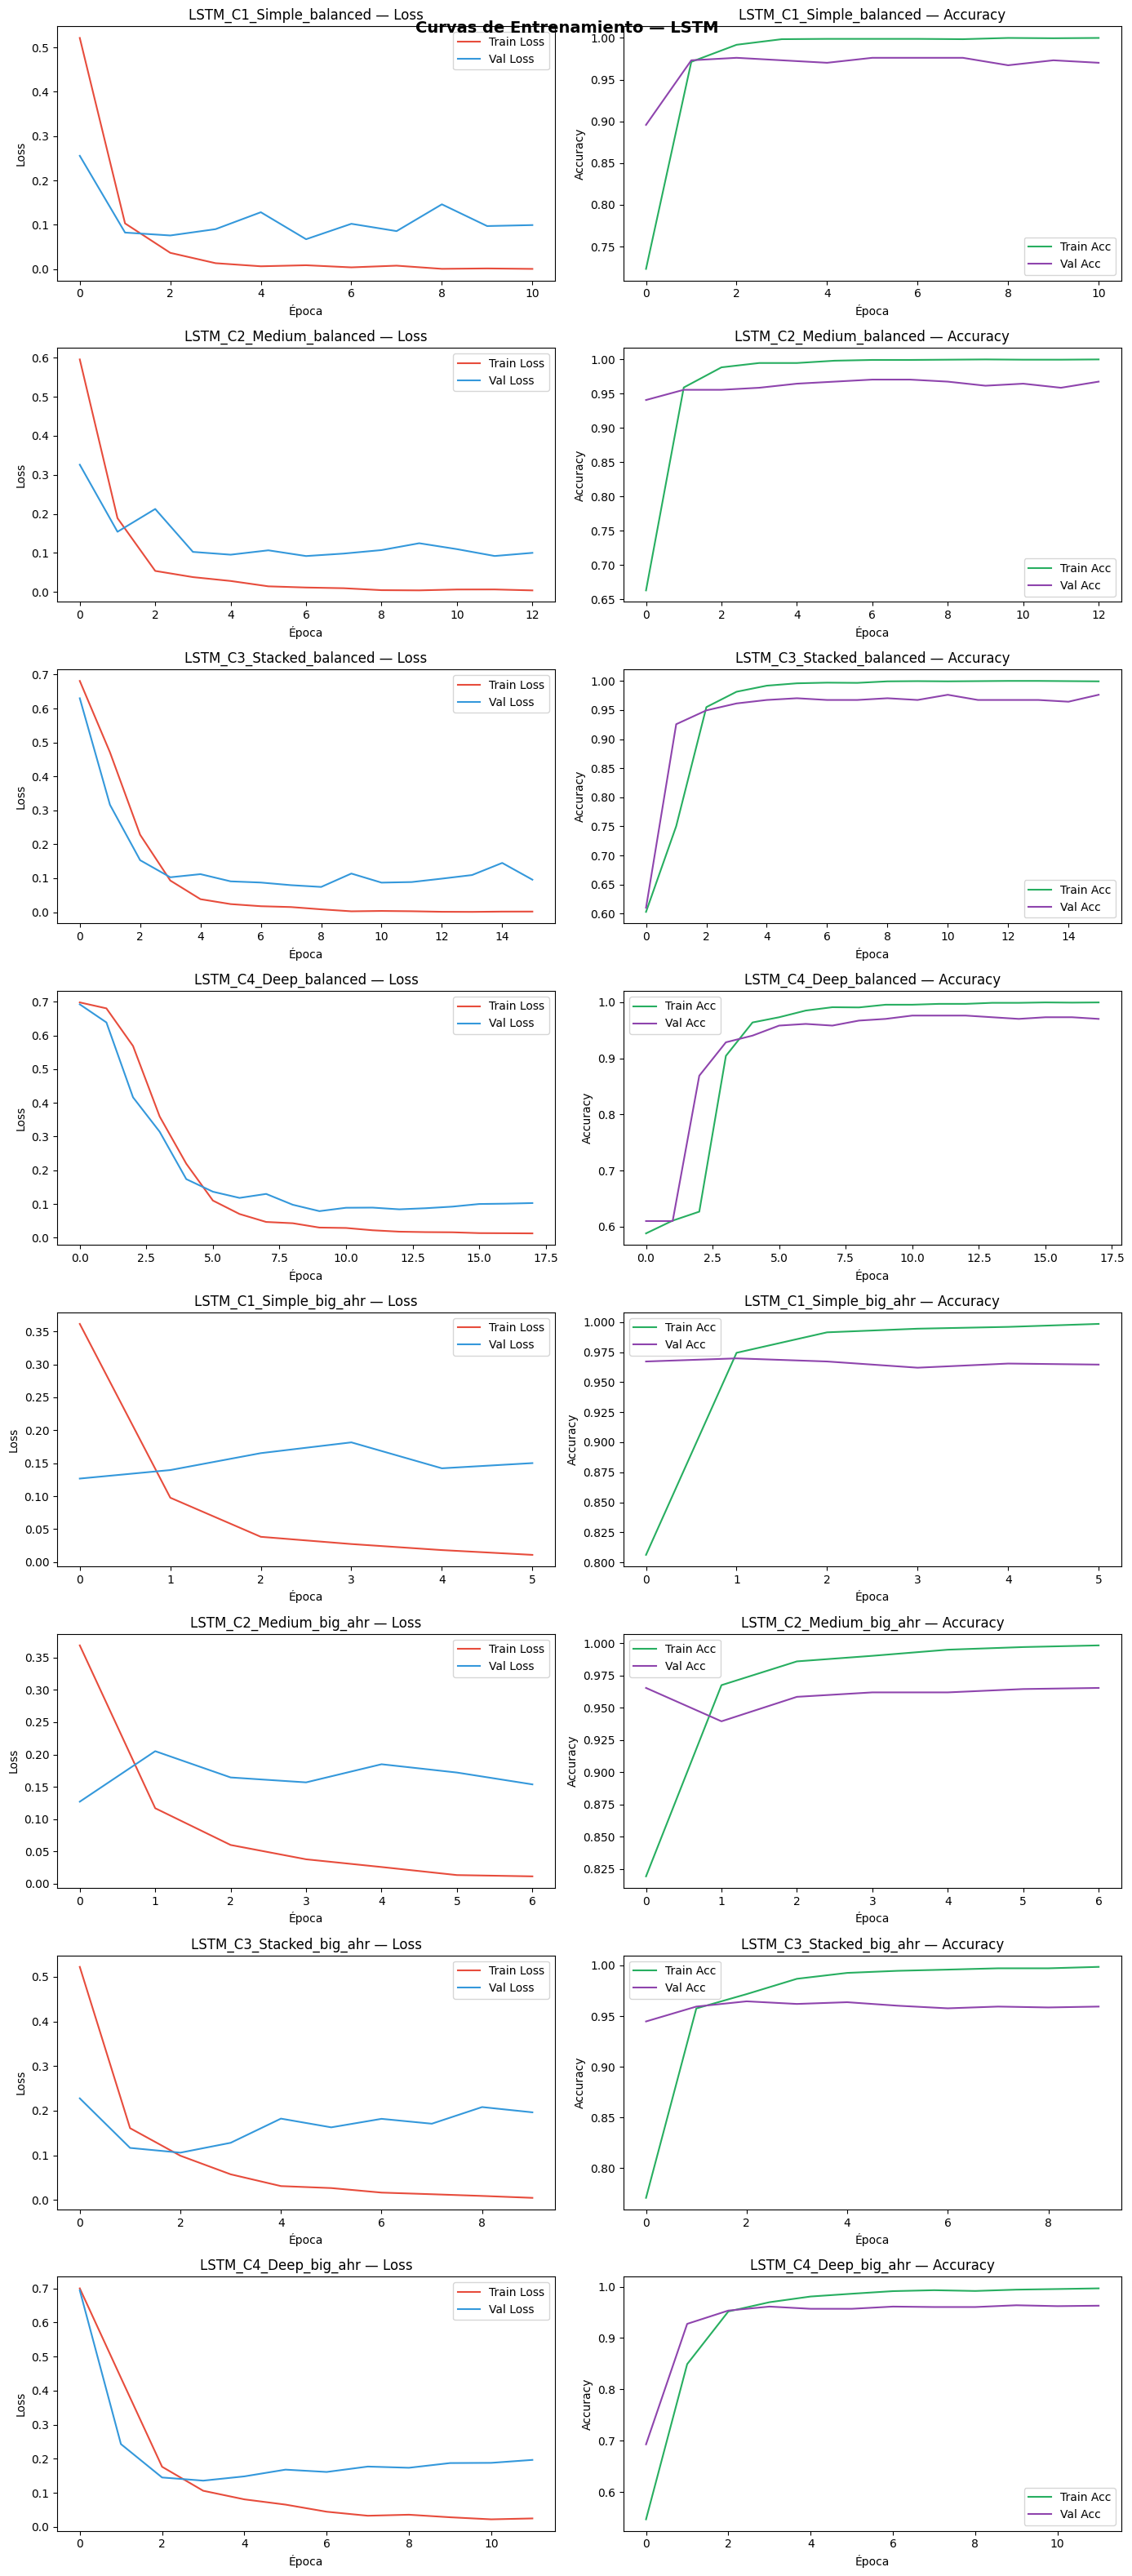

✅ results\figures\LSTM_training_curves.png


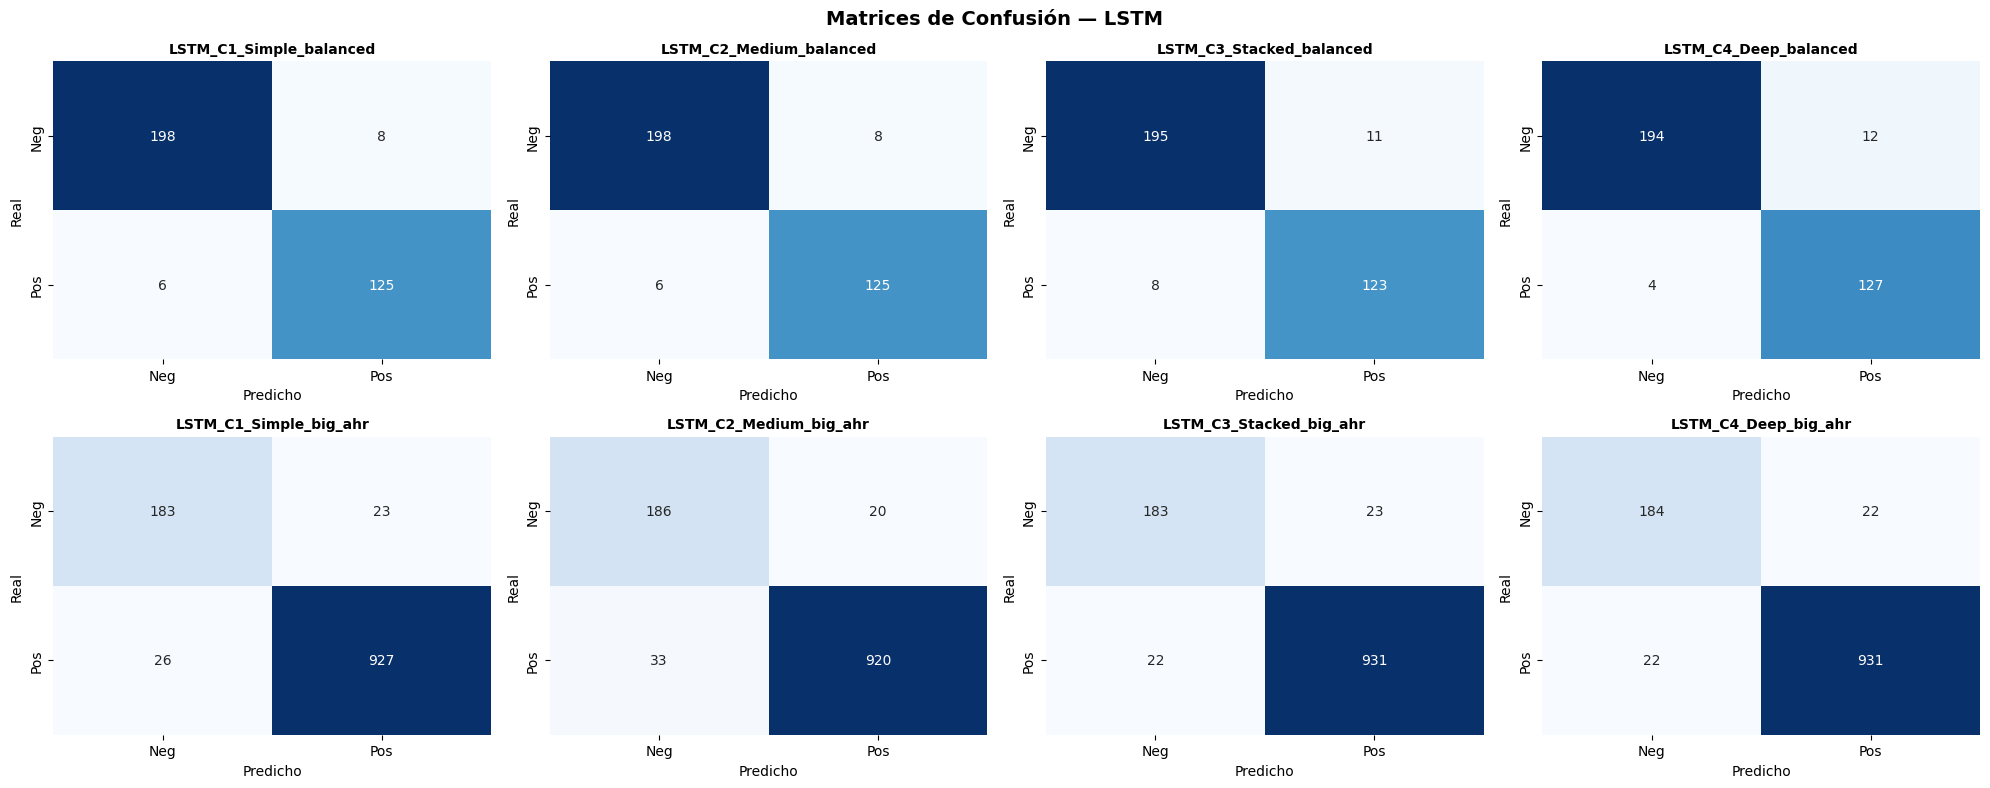

✅ results\figures\LSTM_confusion_matrices.png


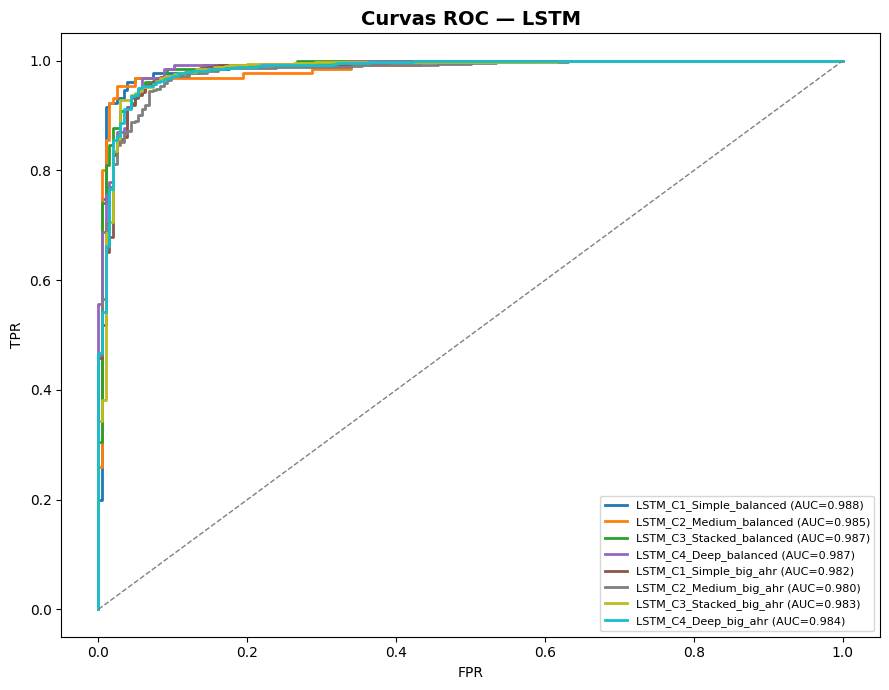

In [6]:
plot_training_curves(all_histories, "LSTM")
plot_confusion_matrices(conf_matrix_data, "LSTM")
plot_roc_curves(roc_data, "LSTM")

## 5. Tabla Comparativa y Guardado

✅ Métricas guardadas: results\metrics\LSTM_results.json

         Modelo  Dataset  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 LSTM_C1_Simple balanced  0.958457   0.939850 0.954198  0.946970 0.988068
 LSTM_C2_Medium balanced  0.958457   0.939850 0.954198  0.946970 0.984844
LSTM_C3_Stacked balanced  0.943620   0.917910 0.938931  0.928302 0.987327
   LSTM_C4_Deep balanced  0.952522   0.913669 0.969466  0.940741 0.987179
 LSTM_C1_Simple  big_ahr  0.957722   0.975789 0.972718  0.974251 0.982355
 LSTM_C2_Medium  big_ahr  0.954271   0.978723 0.965373  0.972002 0.979737
LSTM_C3_Stacked  big_ahr  0.961173   0.975891 0.976915  0.976403 0.983084
   LSTM_C4_Deep  big_ahr  0.962036   0.976915 0.976915  0.976915 0.984031

✅ Tabla guardada: results\metrics\LSTM_summary.csv


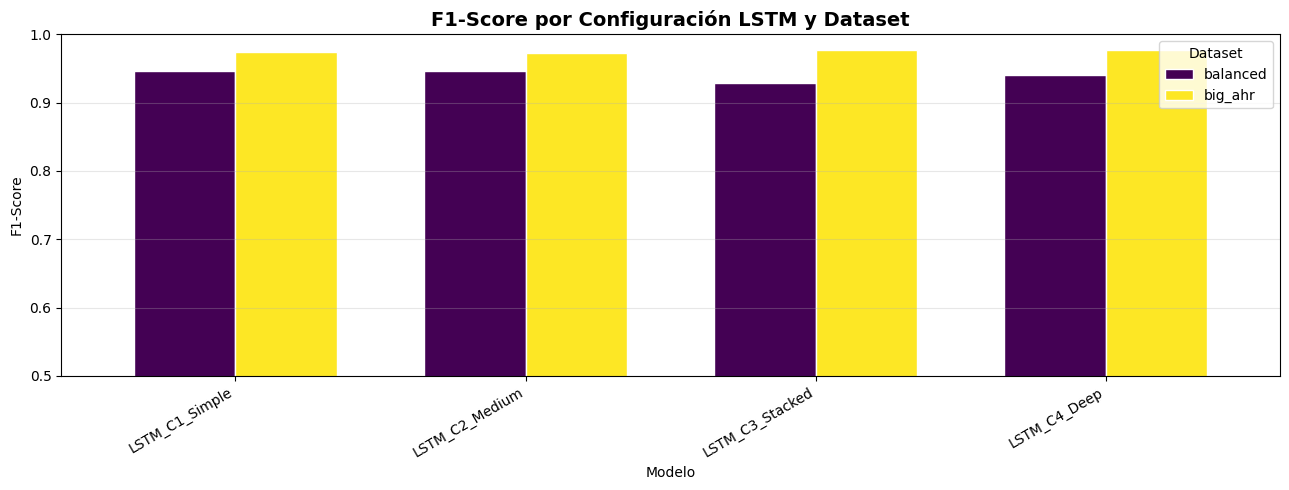

In [7]:
save_metrics(all_results, "LSTM")
df_summary = summarize_results(all_results, "LSTM")

# Barplot F1-Score
import pandas as pd
fig, ax = plt.subplots(figsize=(13, 5))
pivot = df_summary.pivot(index="Modelo", columns="Dataset", values="F1-Score")
pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white', width=0.7)
ax.set_title("F1-Score por Configuración LSTM y Dataset", fontsize=14, fontweight='bold')
ax.set_ylabel("F1-Score"); ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title="Dataset"); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "LSTM_f1_comparison.png"), dpi=130)
plt.show()